In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(100, 80),
            nn.ReLU(),
            nn.Linear(80, 50),
            nn.ReLU(),
            nn.Linear(50, 30),
            nn.ReLU(),
            nn.Linear(30, 10)    # Reduzindo para 10 pontos
        )
        self.decoder = nn.Sequential(
            nn.Linear(10, 30),
            nn.ReLU(),
            nn.Linear(30, 50),
            nn.ReLU(),
            nn.Linear(50, 80),
            nn.ReLU(),
            nn.Linear(80, 100)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

## Geradores de sinais

In [3]:
def gera_sin(freq, data_size):
    
    x = np.linspace(-1, 1, data_size)
    y = np.sin(2*np.pi*freq*x)
    
    return y

In [4]:
def onda_triangular(frequencia, numero_elementos):
    # Gere o vetor de tempo
    tempo = np.linspace(0, 1, numero_elementos, endpoint=False)

    # Calcule a onda triangular variando de -1 até 1
    onda = 1 - 4 * np.abs(tempo * frequencia - np.floor(tempo * frequencia + 0.5))

    return onda

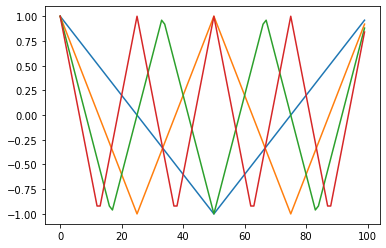

In [5]:
z_1 = onda_triangular(1, 100)
z_2 = onda_triangular(2, 100)
z_3 = onda_triangular(3, 100)
z_4 = onda_triangular(4, 100)
plt.plot(z_1)
plt.plot(z_2)
plt.plot(z_3)
plt.plot(z_4)
plt.show()

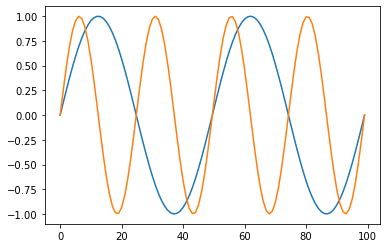

In [6]:
y_1 = gera_sin(1, 100)
y_2 = gera_sin(2, 100)
y_3 = gera_sin(0.5, 100)
y_4 = gera_sin(4, 100)
plt.plot(y_1)
plt.plot(y_2)
#plt.plot(y_3)
#plt.plot(y_4)
plt.show()

## Treinamento

In [7]:
# Inicializando o modelo e o otimizador
AE_sin = Autoencoder()
AE_tri = Autoencoder()
criterion = nn.MSELoss()
optimizer_sin = optim.Adam(AE_sin.parameters(), lr=0.01)
optimizer_tri = optim.Adam(AE_tri.parameters(), lr=0.01)
num_epochs = 100_000

In [8]:
# Treinamento do autoencoder da senoide
for epoch in range(num_epochs):
    freq = 4*np.random.rand() # Freq variando de 0 a 4
    wave = gera_sin(freq, 100)
    
    tensor_input = torch.Tensor(wave).view(1, -1)
    # Forward pass
    outputs = AE_sin(tensor_input)
    loss = criterion(outputs, tensor_input)

    # Backward pass e otimização
    optimizer_sin.zero_grad()
    loss.backward()
    optimizer_sin.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
    if loss.item() < 0.005:
        print(f'Epoch final: {epoch+1}, Loss: {loss.item():.4f}')
        break

Epoch [1000/100000], Loss: 0.3051
Epoch [2000/100000], Loss: 0.4116
Epoch [3000/100000], Loss: 0.4312
Epoch [4000/100000], Loss: 0.4524
Epoch [5000/100000], Loss: 0.4335
Epoch [6000/100000], Loss: 0.4808
Epoch [7000/100000], Loss: 0.4104
Epoch [8000/100000], Loss: 0.4878
Epoch [9000/100000], Loss: 0.4249
Epoch [10000/100000], Loss: 0.4415
Epoch [11000/100000], Loss: 0.4459
Epoch [12000/100000], Loss: 0.4969
Epoch [13000/100000], Loss: 0.5570
Epoch [14000/100000], Loss: 0.4907
Epoch [15000/100000], Loss: 0.4381
Epoch [16000/100000], Loss: 0.4309
Epoch [17000/100000], Loss: 0.4233
Epoch [18000/100000], Loss: 0.4225
Epoch [19000/100000], Loss: 0.4510
Epoch [20000/100000], Loss: 0.4416
Epoch [21000/100000], Loss: 0.4556
Epoch [22000/100000], Loss: 0.4618
Epoch [23000/100000], Loss: 0.3864
Epoch [24000/100000], Loss: 0.4418
Epoch [25000/100000], Loss: 0.4394
Epoch [26000/100000], Loss: 0.4218
Epoch [27000/100000], Loss: 0.4795
Epoch [28000/100000], Loss: 0.4457
Epoch [29000/100000], Loss: 0

In [9]:
# Treinamento do autoencoder da onda triangular
for epoch in range(num_epochs):
    freq = 4*np.random.rand() # Freq variando de 0 a 4
    wave = onda_triangular(freq, 100)
    
    tensor_input = torch.Tensor(wave).view(1, -1)
    # Forward pass
    outputs = AE_tri(tensor_input)
    loss = criterion(outputs, tensor_input)

    # Backward pass e otimização
    optimizer_tri.zero_grad()
    loss.backward()
    optimizer_tri.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
        
    if loss.item() < 0.005:
        print(f'Epoch final: {epoch+1}, Loss: {loss.item():.4f}')
        break

Epoch [1000/100000], Loss: 0.2810
Epoch [2000/100000], Loss: 0.2104
Epoch [3000/100000], Loss: 0.2888
Epoch [4000/100000], Loss: 0.2936
Epoch [5000/100000], Loss: 0.2548
Epoch [6000/100000], Loss: 0.0843
Epoch [7000/100000], Loss: 0.4775
Epoch [8000/100000], Loss: 0.2902
Epoch [9000/100000], Loss: 0.2846
Epoch [10000/100000], Loss: 0.3163
Epoch final: 10310, Loss: 0.0046


## Teste de reconstrução

In [10]:
tensor_y_1 = torch.Tensor(y_1).view(1, -1)

In [11]:
tensor_y_1

tensor([[ 2.4493e-16,  1.2659e-01,  2.5115e-01,  3.7166e-01,  4.8620e-01,
          5.9291e-01,  6.9008e-01,  7.7615e-01,  8.4973e-01,  9.0963e-01,
          9.5490e-01,  9.8481e-01,  9.9887e-01,  9.9685e-01,  9.7880e-01,
          9.4500e-01,  8.9599e-01,  8.3257e-01,  7.5575e-01,  6.6677e-01,
          5.6706e-01,  4.5823e-01,  3.4202e-01,  2.2031e-01,  9.5056e-02,
         -3.1728e-02, -1.5800e-01, -2.8173e-01, -4.0093e-01, -5.1368e-01,
         -6.1816e-01, -7.1269e-01, -7.9576e-01, -8.6603e-01, -9.2235e-01,
         -9.6384e-01, -9.8982e-01, -9.9987e-01, -9.9384e-01, -9.7181e-01,
         -9.3415e-01, -8.8145e-01, -8.1458e-01, -7.3459e-01, -6.4279e-01,
         -5.4064e-01, -4.2979e-01, -3.1203e-01, -1.8925e-01, -6.3424e-02,
          6.3424e-02,  1.8925e-01,  3.1203e-01,  4.2979e-01,  5.4064e-01,
          6.4279e-01,  7.3459e-01,  8.1458e-01,  8.8145e-01,  9.3415e-01,
          9.7181e-01,  9.9384e-01,  9.9987e-01,  9.8982e-01,  9.6384e-01,
          9.2235e-01,  8.6603e-01,  7.

In [12]:
y_1_dec = AE_sin(tensor_y_1)
y_1_dec

tensor([[-0.0467, -0.0527, -0.0636, -0.0760, -0.0854, -0.0875, -0.0801, -0.0634,
         -0.0398, -0.0142,  0.0072,  0.0184,  0.0155, -0.0023, -0.0332, -0.0724,
         -0.1125, -0.1444, -0.1607, -0.1591, -0.1416, -0.1130, -0.0804, -0.0535,
         -0.0419, -0.0513, -0.0810, -0.1256, -0.1768, -0.2238, -0.2535, -0.2538,
         -0.2200, -0.1569, -0.0757,  0.0084,  0.0764,  0.1086,  0.0899,  0.0156,
         -0.1077, -0.2650, -0.4353, -0.5955, -0.7159, -0.7651, -0.7264, -0.5997,
         -0.3953, -0.1438,  0.1438,  0.3953,  0.5997,  0.7264,  0.7651,  0.7159,
          0.5955,  0.4353,  0.2650,  0.1077, -0.0156, -0.0899, -0.1086, -0.0764,
         -0.0084,  0.0757,  0.1569,  0.2200,  0.2538,  0.2535,  0.2238,  0.1768,
          0.1256,  0.0810,  0.0513,  0.0419,  0.0535,  0.0804,  0.1130,  0.1416,
          0.1591,  0.1607,  0.1444,  0.1125,  0.0724,  0.0332,  0.0023, -0.0155,
         -0.0184, -0.0072,  0.0142,  0.0398,  0.0634,  0.0801,  0.0875,  0.0854,
          0.0760,  0.0636,  

In [13]:
y_1_dec.detach().numpy()

array([[-0.04674434, -0.05266735, -0.06363481, -0.07603752, -0.0853558 ,
        -0.08749787, -0.08013255, -0.06336806, -0.0397801 , -0.01416076,
         0.00724111,  0.01840469,  0.01549266, -0.00232837, -0.03315515,
        -0.07237184, -0.11248326, -0.14436683, -0.16071102, -0.15907668,
        -0.14155781, -0.11296374, -0.08042159, -0.05345816, -0.04185947,
        -0.05126332, -0.08097161, -0.12558734, -0.17681657, -0.2238104 ,
        -0.25346458, -0.25377294, -0.22004819, -0.15694386, -0.07565312,
         0.0083882 ,  0.07643735,  0.10863519,  0.08991013,  0.01564778,
        -0.10773231, -0.2650095 , -0.4353496 , -0.5954646 , -0.71590626,
        -0.7650531 , -0.72644395, -0.5996707 , -0.39525524, -0.14382419,
         0.14382419,  0.39525524,  0.5996707 ,  0.72644395,  0.7650531 ,
         0.71590626,  0.5954646 ,  0.4353496 ,  0.2650095 ,  0.10773231,
        -0.01564778, -0.08991013, -0.10863519, -0.07643735, -0.0083882 ,
         0.07565312,  0.15694386,  0.22004819,  0.2

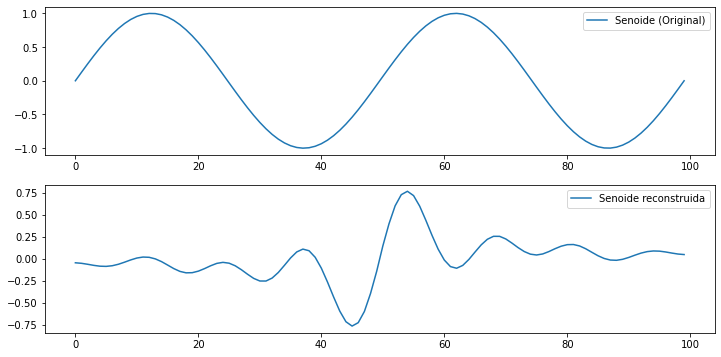

In [14]:
# Visualizando os resultados
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(tensor_y_1.squeeze().numpy(), label='Senoide (Original)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(y_1_dec.detach().squeeze().numpy(), label='Senoide reconstruida')
plt.legend()

In [15]:
tensor_y_2 = torch.Tensor(y_2).view(1, -1)
y_2_dec = AE_sin(tensor_y_2)

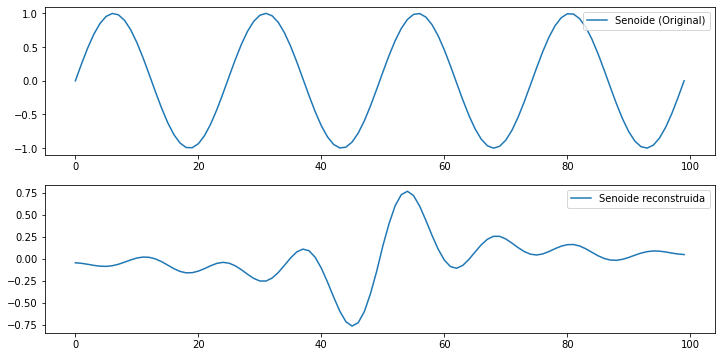

In [16]:
# Visualizando os resultados
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(tensor_y_2.squeeze().numpy(), label='Senoide (Original)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(y_2_dec.detach().squeeze().numpy(), label='Senoide reconstruida')
plt.legend()

In [17]:
tensor_z_3 = torch.Tensor(z_3).view(1, -1)
z_3_dec = AE_tri(tensor_z_3)

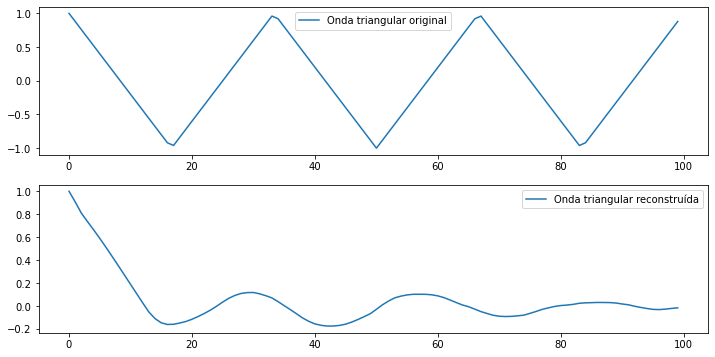

In [18]:
# Visualizando os resultados
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(tensor_z_3.squeeze().numpy(), label='Onda triangular original')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(z_3_dec.detach().squeeze().numpy(), label='Onda triangular reconstruída')
plt.legend()